# MODELIZACIÓN PARA NO SUPERVISADO

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

from sklearn.model_selection import GridSearchCV

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
ruta_proyecto = 'C:/Users/sergi/Desktop/DATA/CURSO DS4B/EstructuraDirectorio/03_MACHINE_LEARNING/08_CASOS/01_LEADSCORING'

Nombres de los ficheros de datos.

In [3]:
nombre_df = 'df_tablon.pickle'

Cargar los datos.

In [4]:
df = pd.read_pickle(ruta_proyecto + '/02_Datos/03_Trabajo/' + nombre_df)
df

,origen_API,origen_Landing Page Submission,origen_Lead Add Form,origen_OTROS,fuente_Chat,fuente_Direct Traffic,fuente_Google,fuente_OTROS,fuente_Organic Search,fuente_Reference,...,ocupacion_Student,ocupacion_Unemployed,ocupacion_Working Professional,descarga_lm_No,descarga_lm_Yes,tiempo_en_site_total_mms,paginas_vistas_visita_mms,score_actividad_mms,score_perfil_mms,compra
id,,,,,,,,,,,,,,,,,,,,,
660737,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.73,0.44,0
660728,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,1.00,0.00,1.00,0.00,0.30,0.12,0.73,0.44,0
660680,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.91,0.44,0
660673,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,0.72,0.10,0.64,1.00,1
660664,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.73,0.44,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579642,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,1.00,0.78,0.10,0.64,1.00,0
579622,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,0.62,0.13,0.64,0.56,1
579615,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,1.00,0.00,0.09,0.12,0.64,1.00,1


In [5]:
df.drop(columns = ['fuente_Chat',
                   'fuente_Direct Traffic',
                   'fuente_Google',
                   'fuente_OTROS',
                   'fuente_Organic Search',
                   'fuente_Reference',
                   'score_actividad_mms',
                   'score_perfil_mms',
                   'ambito_Banking, Investment And Insurance',
                   'ambito_Business Administration',
                   'ambito_Finance Management',
                   'ambito_Human Resource Management',
                   'ambito_IT Projects Management',
                   'ambito_International Business',
                   'ambito_Marketing Management',
                   'ambito_Media and Advertising',
                   'ambito_OTROS',
                   'ambito_Operations Management',
                   'ambito_Select',
                   'ambito_Supply Chain Management',
                   'ambito_Travel and Tourism',
                   'descarga_lm_No','descarga_lm_Yes','paginas_vistas_visita_mms'], inplace = True)

## MODELIZAR

### Crear el espacio de soluciones

In [6]:
min_k = 3
max_k = 7

soluciones = list(range(min_k,max_k))

### Crear listas para guardar la salida de cada métrica

In [7]:
codo = []
silueta = []
calins = []
davies = []

### Analizar el espacio de soluciones

In [8]:
for solucion in soluciones:
    
    #Instanciar
    cluster = KMeans(n_clusters = solucion, n_init=10)
    
    #Entrenar
    cluster.fit(df)
    
    #Recoger las métricas
    codo.append(cluster.inertia_)
    silueta.append(silhouette_score(df, cluster.labels_))
    calins.append(calinski_harabasz_score(df, cluster.labels_))
    davies.append(davies_bouldin_score(df, cluster.labels_))

### Identificar la mejor solucion

#### Analizar las métricas

In [9]:
metricas = pd.DataFrame({'Solucion':soluciones,
              'Codo': codo,
              'Silueta':silueta,
              'Calins':calins,           
              'Davies':davies}).set_index('Solucion')

metricas

,Codo,Silueta,Calins,Davies
Solucion,,,,
3,5221.04,0.29,1403.31,1.50
4,4606.46,0.31,1273.07,1.31
5,4089.51,0.33,1226.55,1.37
6,3637.38,0.38,1221.96,1.49


#### Analizar los gráficos

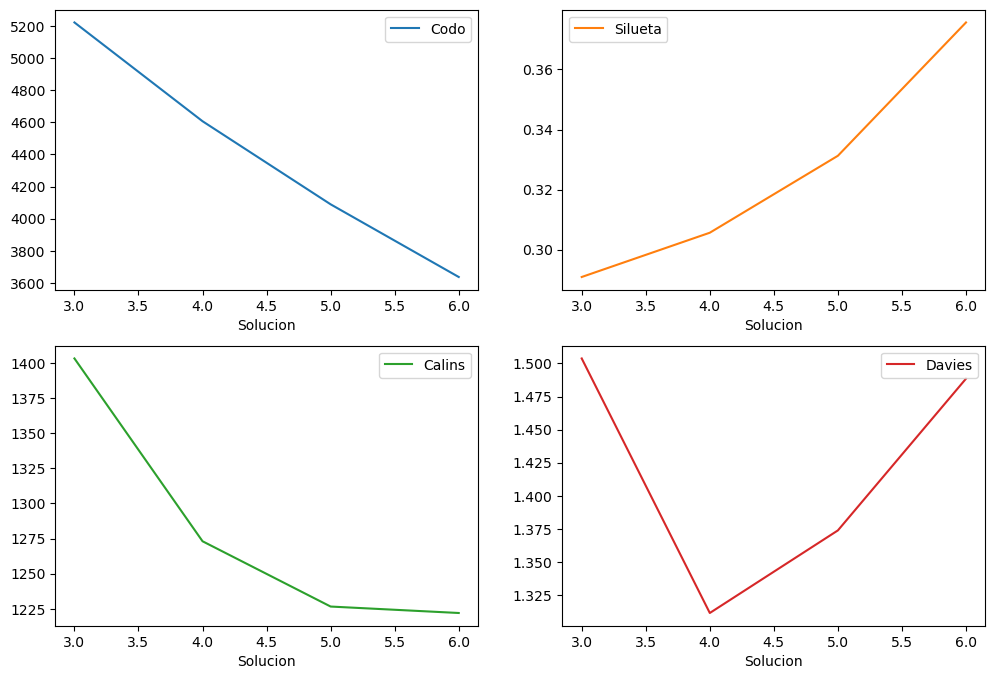

In [10]:
metricas.plot(subplots = True, figsize = (12,8), layout = (2,2), sharex = False);

### Segmentación final con la mejor solucion

In [11]:
mejor_solucion = 6

#Instanciar
cluster = KMeans(n_clusters = mejor_solucion, n_init=10)
    
#Entrenar
cluster.fit(df)

KMeans(n_clusters=6, n_init=10)

## EVALUAR

In [11]:
df['segmento'] = cluster.predict (df)

### Comparar los perfiles

## PERFILAR LOS SEGMENTOS

In [12]:
df.groupby('segmento').mean().T \
    .style.highlight_max(color = 'lightgreen', axis = 1) \
    .highlight_min(color = 'red', axis = 1)

segmento,0,1,2,3,4,5
origen_API,0.880282,0.000000,0.212121,1.000000,0.000000,0.000000
origen_Landing Page Submission,0.000000,0.949231,0.573427,0.000000,0.990312,0.978462
origen_Lead Add Form,0.114085,0.040000,0.212121,0.000000,0.004306,0.009231
origen_OTROS,0.005634,0.010769,0.002331,0.000000,0.005382,0.012308
ult_actividad_Chat Conversation,0.047887,0.000000,0.016317,0.215762,0.000000,0.070769
ult_actividad_Converted to Lead,0.011268,0.000000,0.027972,0.122739,0.000000,0.269231
ult_actividad_Email Link Clicked,0.021127,0.000000,0.020979,0.050388,0.000000,0.121538
ult_actividad_Email Opened,0.257746,1.000000,0.386946,0.468992,0.000000,0.000000
ult_actividad_OTROS,0.078873,0.000000,0.083916,0.033592,0.000000,0.167692
ult_actividad_Page Visited on Website,0.029577,0.000000,0.044289,0.108527,0.000000,0.370769


In [14]:
df.segmento.value_counts(normalize = True)

segmento
3   0.26
2   0.20
5   0.19
4   0.13
1   0.13
0   0.09
Name: proportion, dtype: float64